In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('titanic_data_updated.csv')
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [4]:
df.shape

(891, 12)

In [5]:
df.shape[0]

891

In [6]:
df.shape[1]

12

In [7]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [8]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
337,338,yes,first,"Burns, Miss. Elizabeth Margaret",female,41.00,0,0,16966,134.5000,E40,C
467,468,no,first,"Smart, Mr. John Montgomery",male,56.00,0,0,113792,26.5500,NaN,S
722,723,no,second,"Gillespie, Mr. William Henry",male,34.00,0,0,12233,13.0000,NaN,S
803,804,yes,third,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
69,70,no,third,"Kink, Mr. Vincenz",male,26.00,2,0,315151,8.6625,NaN,S
829,830,yes,first,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.00,0,0,113572,80.0000,B28,NaN
260,261,no,third,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.7500,NaN,Q
479,480,yes,third,"Hirvonen, Miss. Hildur E",female,2.00,0,1,3101298,12.2875,NaN,S
407,408,yes,second,"Richards, Master. William Rowe",male,3.00,1,1,29106,18.7500,NaN,S
884,885,no,third,"Sutehall, Mr. Henry Jr",male,25.00,0,0,SOTON/OQ 392076,7.0500,NaN,S


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

# ১. Incorrect Data Type
ডেটার টাইপ যদি সঠিক না থাকে, তবে মডেল কাজ করবে না।

উদাহরণ: 'Salary' কলামে সংখ্যা থাকার কথা (যেমন: ৫০০০), কিন্তু সেখানে যদি টেক্সট হিসেবে থাকে ("5000"), তবে গাণিতিক হিসাব করা যাবে না। এটি স্ক্রিনিং করে ঠিক করতে হয়।

# ২. Constant Feature
যে কলামের সব ভ্যালু একই, সেটি মডেলের জন্য কোনো কাজে আসে না।

উদাহরণ: একটি ছাত্র তালিকা যেখানে সবার 'Country' হলো 'Bangladesh'। যেহেতু এখানে কোনো ভিন্নতা নেই, তাই এটি প্রেডিকশনে কোনো ভূমিকা রাখবে না। এটি বাদ দেওয়া হয়।

# ৩. High Cardinality
ক্যাটাগরিক্যাল ফিচারে যদি অনেক বেশি সংখ্যক ইউনিক ভ্যালু থাকে।

উদাহরণ: 'Customer Name' বা 'PIN Code'। একটি ডেটাসেটে যদি ১০,০০০ রো থাকে এবং সেখানে ৯,০০০টি আলাদা পিন কোড থাকে, তবে মডেলটি কনফিউজড হয়ে যেতে পারে। একে হ্যান্ডেল করা জরুরি।

# ৪. Irrelevant Feature
এমন ফিচার যা টার্গেট ভেরিয়েবলের সাথে মোটেও সম্পর্কিত নয়।

উদাহরণ: কেউ লোন পাবে কি না তা প্রেডিক্ট করার সময় তার 'Favorite Color' বা 'Pet's Name' জানার কোনো প্রয়োজন নেই। এগুলো অপ্রাসঙ্গিক ফিচার।

# ৫. Unique Identifier
এটি মূলত ডেটাবেজের আইডি যা প্রতিটি রো-এর জন্য আলাদা।

উদাহরণ: 'Student ID' বা 'Transaction Hash'। এগুলো ট্রেন্ড বোঝার জন্য নয়, বরং নির্দিষ্ট রো চেনার জন্য ব্যবহৃত হয়। মডেল ট্রেনিংয়ের সময় এগুলো বাদ দিতে হয়।

# ৬. Data Imbalance
টার্গেট ক্লাসে যদি একটির তুলনায় অন্যটি খুব বেশি বা কম থাকে।

উদাহরণ: ক্যান্সার ডিটেকশন ডেটাসেটে ১,০০০ জনের মধ্যে ৯৯৯ জন সুস্থ এবং মাত্র ১ জন অসুস্থ। এক্ষেত্রে মডেলটি সবাইকে "সুস্থ" হিসেবে প্রেডিক্ট করার চেষ্টা করবে। স্ক্রিনিংয়ের মাধ্যমে এটি চিহ্নিত করে ব্যালেন্স করতে হয়।

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [13]:
df.sample(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
245,246,no,first,"Minahan, Dr. William Edward",male,44.0,2,0,19928,90.0,C78,Q


In [14]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [16]:
df['Survived'].value_counts()

Survived
no     549
yes    342
Name: count, dtype: int64

In [17]:
df['Pclass'].value_counts()

Pclass
third     491
first     216
second    184
Name: count, dtype: int64

In [18]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [22]:
df['Ticket'].unique().shape

(681,)

<Axes: xlabel='Survived', ylabel='count'>

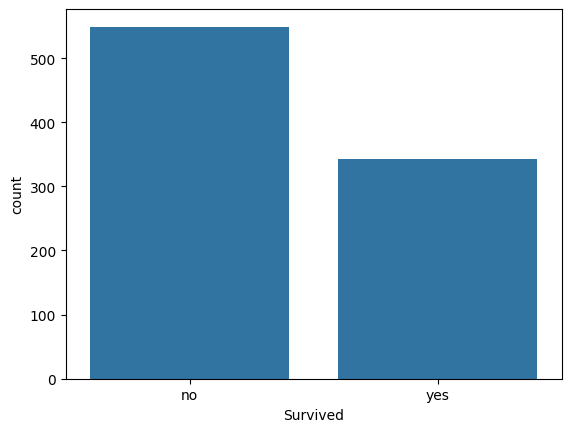

In [23]:
sns.countplot(data = df, x = 'Survived')

In [24]:
df['Survived'].value_counts() / len(df) * 100

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64

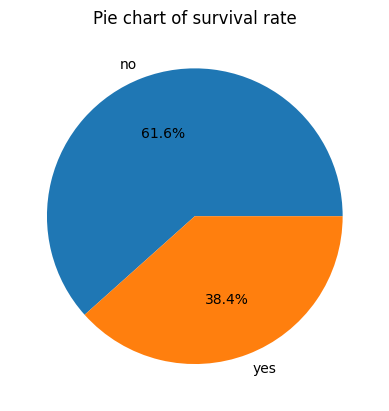

In [28]:
survived_count = df['Survived'].value_counts()
survived_label = df['Survived'].unique()

plt.pie(survived_count, labels = survived_label, autopct = '%1.1f%%')
plt.title('Pie chart of survival rate')
plt.show()

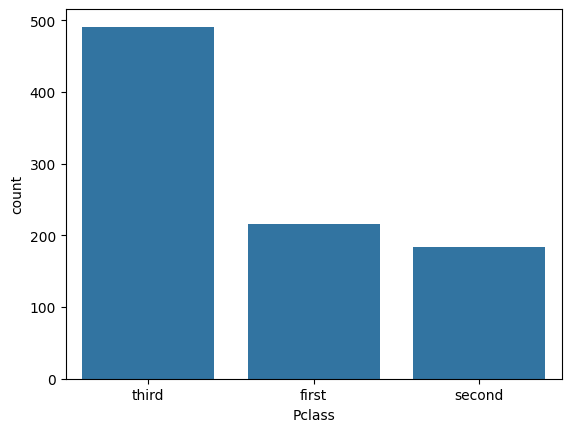

In [31]:
sns.countplot(data = df, x = df['Pclass'])
plt.show()

In [36]:
df['Pclass'].value_counts() / len(df) * 100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

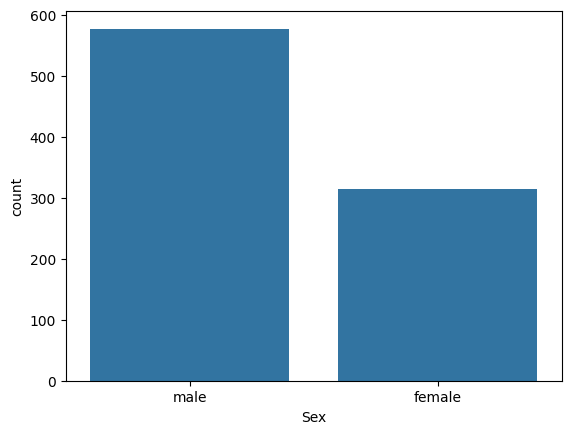

In [37]:
sns.countplot(data = df, x = df['Sex'])

In [38]:
df['Sex'].value_counts() / len(df) * 100

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

<Axes: xlabel='Embarked', ylabel='count'>

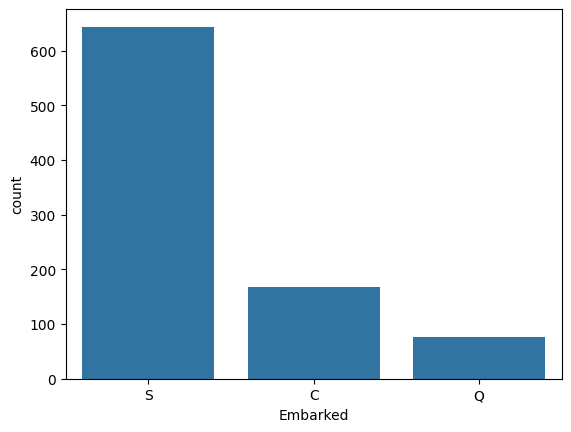

In [39]:
sns.countplot(data = df, x = df['Embarked'])

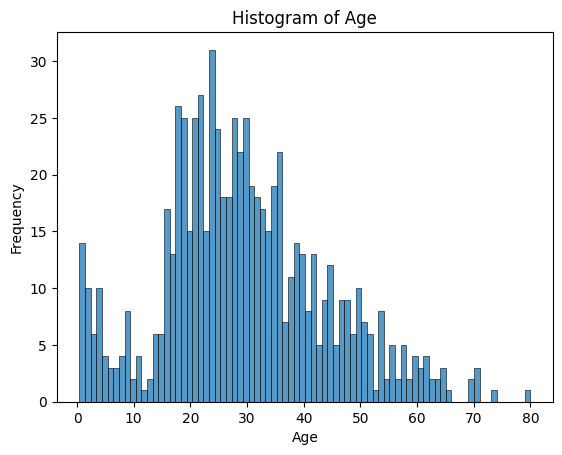

In [43]:
sns.histplot(df['Age'],bins=80)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

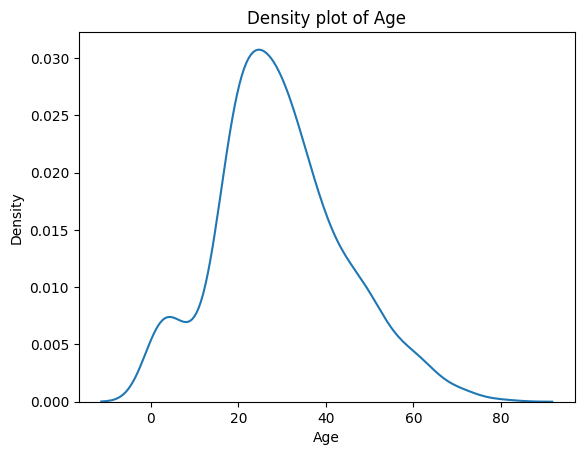

In [45]:
sns.kdeplot(df['Age'])
plt.title('Density plot of Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

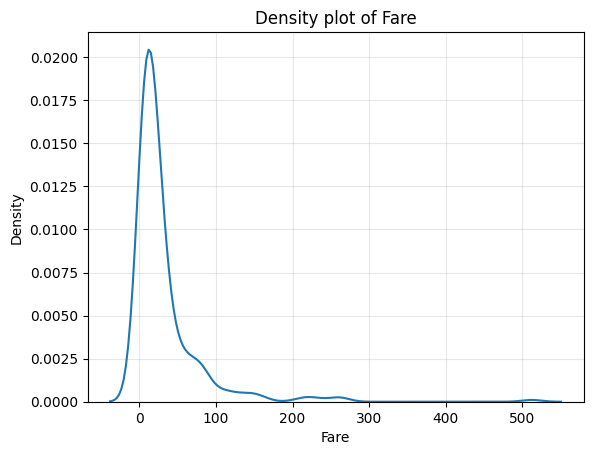

In [50]:
sns.kdeplot(df['Fare'])
plt.title('Density plot of Fare')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.show()

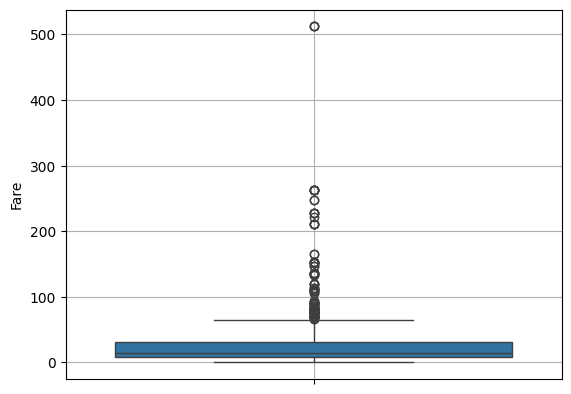

In [52]:
sns.boxplot(df['Fare'])
plt.grid()

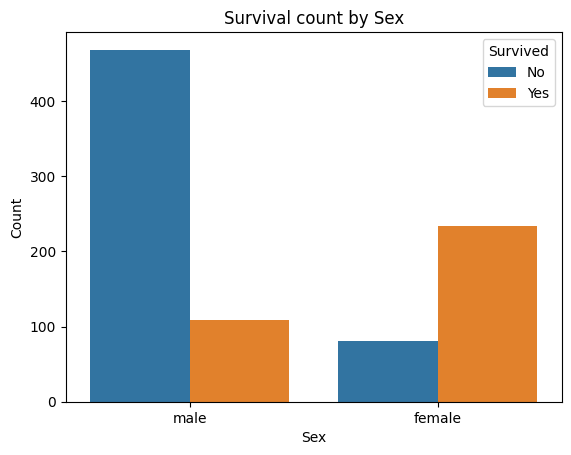

In [54]:
sns.countplot(x = df['Sex'], hue = df['Survived'])
plt.title('Survival count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title = 'Survived', labels = ['No', 'Yes'])
plt.show()

In [56]:
gender_split = df.groupby('Sex')['Survived'].value_counts()
gender_split

Sex     Survived
female  yes         233
        no           81
male    no          468
        yes         109
Name: count, dtype: int64

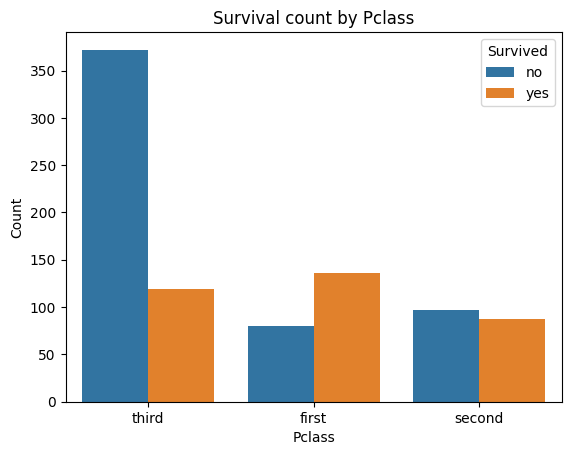

In [57]:
sns.countplot(x = df['Pclass'], hue = df['Survived'])
plt.title('Survival count by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()

In [58]:
pclass_split = df.groupby('Pclass')['Survived'].value_counts()
pclass_split

Pclass  Survived
first   yes         136
        no           80
second  no           97
        yes          87
third   no          372
        yes         119
Name: count, dtype: int64

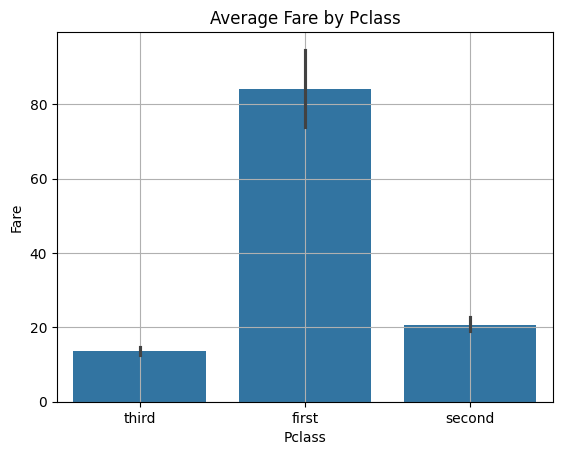

In [62]:
sns.barplot(x = df['Pclass'], y = df['Fare'])
plt.title('Average Fare by Pclass')
plt.grid()
plt.show()

<Axes: xlabel='Survived', ylabel='Age'>

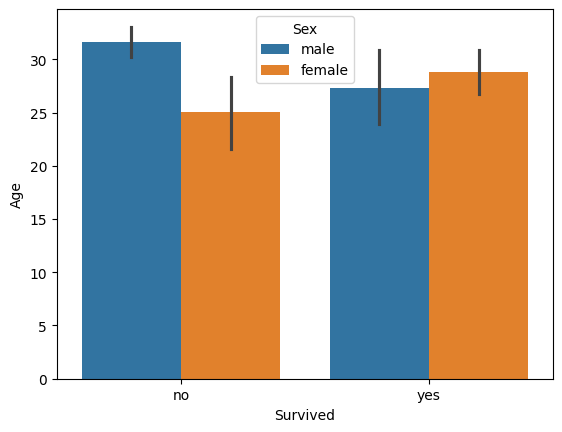

In [63]:
sns.barplot(x = df['Survived'], y = df['Age'], hue = df['Sex'])


<Axes: xlabel='Survived', ylabel='Age'>

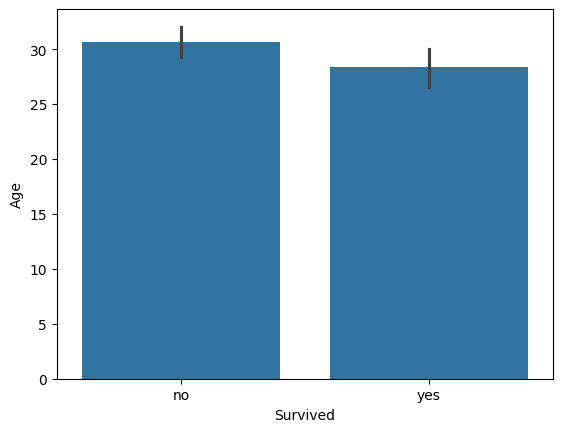

In [64]:
sns.barplot(x = df['Survived'], y = df['Age'])

<Axes: xlabel='Age', ylabel='Density'>

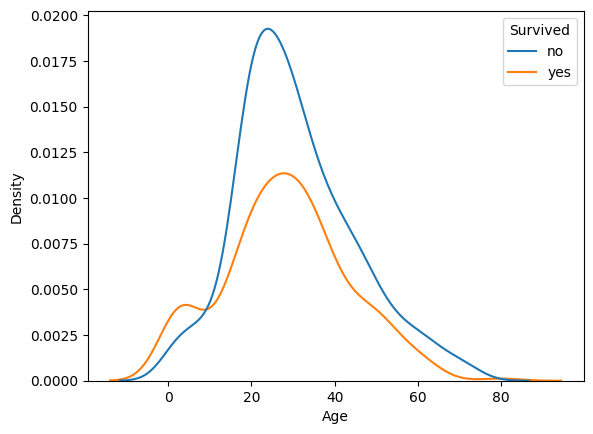

In [65]:
sns.kdeplot(data = df, x = 'Age', hue = 'Survived')

In [66]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [72]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [68]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

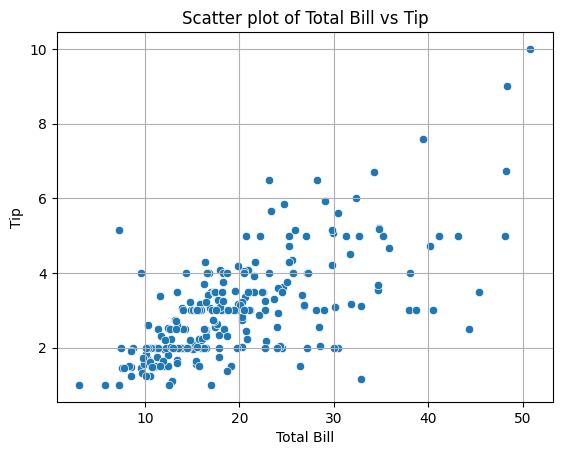

In [70]:
sns.scatterplot(data = df,
                x = 'total_bill',
                y = 'tip')
plt.title('Scatter plot of Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.grid()
plt.show()

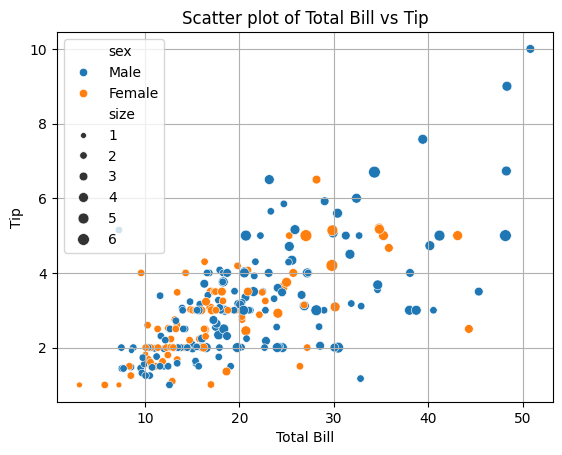

In [71]:
sns.scatterplot(data = df,
                x = 'total_bill',
                y = 'tip',
                hue = 'sex',
                size = 'size')
plt.title('Scatter plot of Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.grid()
plt.show()